In [2]:
%pip install routingpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
from routingpy import Valhalla
from pprint import pprint
import shapely
import pandas as pd
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

In [ ]:
# --- Parameters
ev_range = 120              # 120 km required to be driven before charging batteries again

In [5]:
# read EV charging stations
ev_df = pd.read_csv('output/ev_charging_rovaniemi.csv')

# geodataframe
ev_stations = gpd.GeoDataFrame(ev_df,
                            geometry= gpd.points_from_xy(ev_df['longitude'], ev_df['latitude']),
                            crs='4326'
)

In [18]:
# ------ ISOCHRONES ----------


# Minutes or Kilometers depending the interval type
CATCHMENT_AREAS = [120]


MODES_OF_TRANSPORTATION = ['auto']

def calculate_isochrones(latlons, catchment_areas = CATCHMENT_AREAS, mode_of_interval = 'distance'):
    
    """
    Calculate and aggregate travel-time isochrones for multiple locations and transport modes
    using the Valhalla routing API.

    For each input location and transport mode, this function requests time-based isochrones
    for the specified catchment areas (in minutes). Because the Valhalla API limits the number
    of intervals per request, the catchment areas are chunked into groups of at most four
    (MAX_INTERVALS). Each returned isochrone polygon is collected by transport mode and
    travel-time interval. Polygons corresponding to the same mode and time threshold are
    spatially merged (unioned) into a single geometry.

    Parameters
    ----------
    latlons : list of tuple(float, float)
        A list of (latitude, longitude) coordinate pairs in WGS84 (EPSG:4326) for which
        isochrones will be generated.
    catchment_areas : list of int or float, optional
        Travel-time thresholds in minutes for which isochrones are computed.
        Defaults to the global CATCHMENT_AREAS.
    mode_of_interval : choose time or distance for isochrone.

    Returns
    -------
    geopandas.GeoDataFrame
        A GeoDataFrame containing merged isochrone polygons with columns:
            - "mode_of_transportation" : str
                Transport mode used for routing (from MODES_OF_TRANSPORTATION).
            - "time" : int or float
                Travel-time threshold in seconds (as returned by Valhalla).
            - "geometry" : shapely geometry
                Unioned isochrone polygon for the given mode and time.
        The GeoDataFrame is in CRS EPSG:4326 and sorted in descending order by time.

    Notes
    -----
    - Time intervals are converted from minutes to seconds before being sent to the API.
    - Multiple origin points are aggregated by unioning overlapping isochrone polygons.
    - The function assumes that MODES_OF_TRANSPORTATION and CATCHMENT_AREAS
      are defined in the global scope.
    """
    MAX_INTERVALS = 4 # Valhalla API limit: maximum number of intervals per request
    
    client = Valhalla(retry_over_query_limit=True)

    # Nested dictionary structure:
    # {mode_of_transport: {time_interval: [list_of_polygons]}}
    isochrones_by_trans_by_time = {}

    # Split catchment areas into chunks of size <= MAX_INTERVALS
    # Example: [5,10,15,20,25,30] → [[5,10,15,20],[25,30]]
    chunked_catchments_areas = [
        catchment_areas[i:i + MAX_INTERVALS]
        for i in range(0, len(catchment_areas), MAX_INTERVALS)
    ]
    
    for chunked_catchment_area in chunked_catchments_areas:
        for latlon in latlons:
            for mode_of_transport in MODES_OF_TRANSPORTATION:
                # Convert minutes → seconds because Valhalla expects seconds
                # Example: [5,10] → [300,600]
                isochrones = client.isochrones(
                    locations=latlon,
                    profile=mode_of_transport,
                    # intervals=[c * 60 for c in chunked_catchment_area],
                    intervals=[c * 1000 for c in chunked_catchment_area], # ---- changed for adding meters
                    interval_type=mode_of_interval,
                    polygons=True
                )
        
                for iso in isochrones:
                    
                        isochrones_by_trans_by_time.setdefault(mode_of_transport, {}).setdefault(iso.interval, []).append(Polygon(iso.geometry[0])) # iso.geometry[0] extracts the outer ring of the polygon
                    
    # Merge (union) polygons that share the same mode and time threshold
    # This combines overlapping isochrones from multiple origins
    for mode_of_transport, isochrones_by_time in isochrones_by_trans_by_time.items():
        for time, polygons in isochrones_by_time.items():
            isochrones_by_trans_by_time[mode_of_transport][time] = shapely.union_all(polygons)

    # Flatten nested dictionary into tabular format
    # Each row represents one (mode, time, geometry)
    df = pd.DataFrame(
        [
            (mode_of_transport, time, polygon)
            for mode_of_transport, isochrones_by_time in isochrones_by_trans_by_time.items()
            for time, polygon in isochrones_by_time.items()
        ],
        columns=["mode_of_transportation", "iso", "geometry"]
    )

    final_isochrones = gpd.GeoDataFrame(df, crs="EPSG:4326").sort_values(by="iso", ascending=False)
    
    return final_isochrones

In [19]:
ev_stations.head(2)

,longitude,latitude,geometry
0,25.722570,66.501980,POINT (25.72257 66.50198)
1,25.686167,66.489892,POINT (25.68617 66.48989)


In [20]:
ev_latlons = list(
                    zip(ev_stations.geometry.x,
                        ev_stations.geometry.y)
                )

helsinki_isochrones = calculate_isochrones(ev_latlons)

<Axes: >

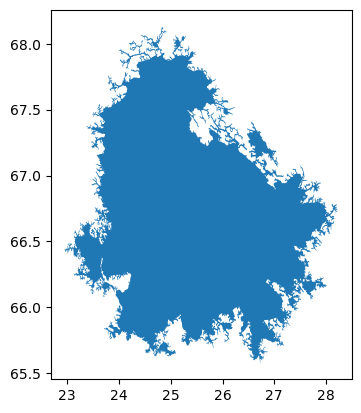

In [21]:
helsinki_isochrones.plot()

In [22]:
helsinki_isochrones.to_file('output/isochones.gpkg')

## Road deficit

In [23]:
roads = gpd.read_parquet('output/road_network_rovaniemi.parquet')

In [24]:
from shapely.ops import unary_union

isochrone_union = helsinki_isochrones.union_all()
roads_clipped = roads.copy()
roads_clipped['geometry'] = roads['geometry'].difference(isochrone_union)

# Drop empty geometries (roads fully inside the isochrone)
roads_outside = roads_clipped[~roads_clipped.is_empty].reset_index(drop=True)

<Axes: >

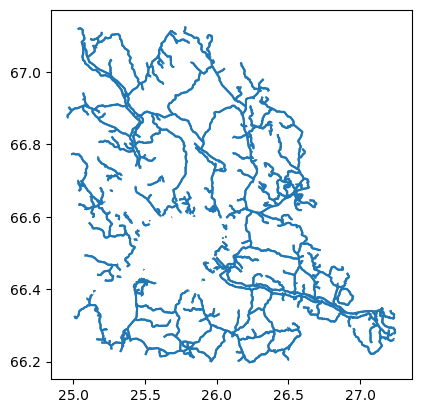

In [17]:
roads_outside.plot()